In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression


# **Dataset**


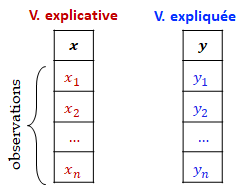

In [86]:
x,y=make_regression(n_samples=100, n_features=1, noise=10)
print(np.shape(x),np.shape(y))

(100, 1) (100,)


In [87]:
y=y.reshape(100,1)
print(np.shape(y))

(100, 1)


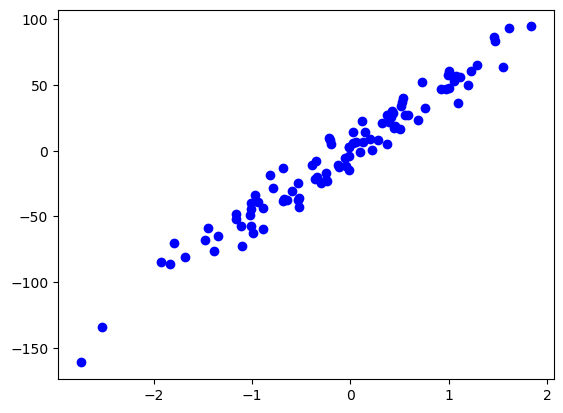

In [88]:
plt.scatter(x,y,c='b')
plt.show()

In [89]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

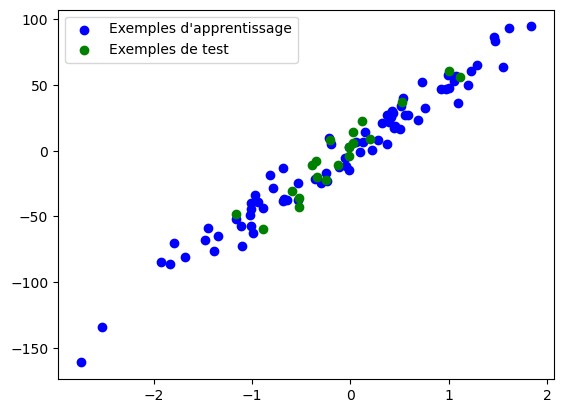

In [90]:
trainPlot=plt.scatter(x_train,y_train,c='b')
testPlot=plt.scatter(x_test,y_test,c='g')
plt.legend([trainPlot,testPlot],["Exemples d'apprentissage","Exemples de test"])
plt.show()

# **Modèle**

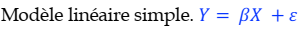

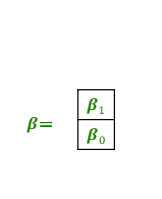

In [36]:
beta=np.random.randn(2,1)
print(np.shape(beta))

(2, 1)


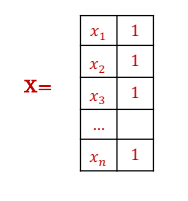

In [91]:

X_train=np.hstack((x_train,np.ones((np.shape(x_train)[0],1))))
X_test=np.hstack((x_test,np.ones((np.shape(x_test)[0],1))))

print(np.shape(X))

(100, 2)


In [49]:
X_train

array([[-0.57897199,  1.        ],
       [ 1.33341709,  1.        ],
       [ 0.24649926,  1.        ],
       [ 0.39215056,  1.        ],
       [-2.00496859,  1.        ],
       [-0.0191437 ,  1.        ],
       [ 0.51775631,  1.        ],
       [ 0.72681105,  1.        ],
       [ 0.63268167,  1.        ],
       [-1.36396813,  1.        ],
       [-1.36865365,  1.        ],
       [ 1.57823865,  1.        ],
       [ 1.22688361,  1.        ],
       [-1.35642468,  1.        ],
       [-0.58789417,  1.        ],
       [-1.52155404,  1.        ],
       [-1.43358543,  1.        ],
       [ 0.8435768 ,  1.        ],
       [ 1.08857657,  1.        ],
       [-0.95964627,  1.        ],
       [ 0.34401126,  1.        ],
       [ 0.45197132,  1.        ],
       [ 0.03997054,  1.        ],
       [ 1.66953773,  1.        ],
       [-0.73155653,  1.        ],
       [-0.44631284,  1.        ],
       [-1.40642384,  1.        ],
       [ 0.21750717,  1.        ],
       [ 0.84643073,

In [92]:
def model(X,beta):
 return X.dot(beta)


In [93]:
y_pred_train= model(X_train,beta)

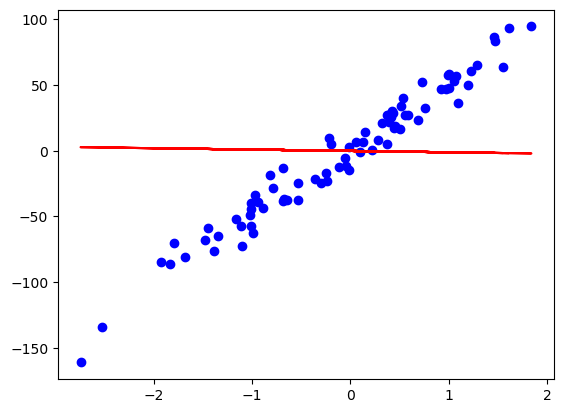

In [94]:
plt.scatter(x_train,y_train,c='b')
plt.plot(x_train,y_pred_train,c='r')
plt.show()

# **Fonction coût**

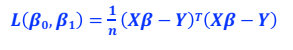

In [95]:
def fonction_cout(X,beta,y):
  n=len(y)
  term=model(X,beta)-y
  return (1/n)*term.T.dot(term)[0,0]


In [96]:
fonction_cout(X_train,beta,y_train)

2722.16105937754

# **Algorithme Desente de gradient**


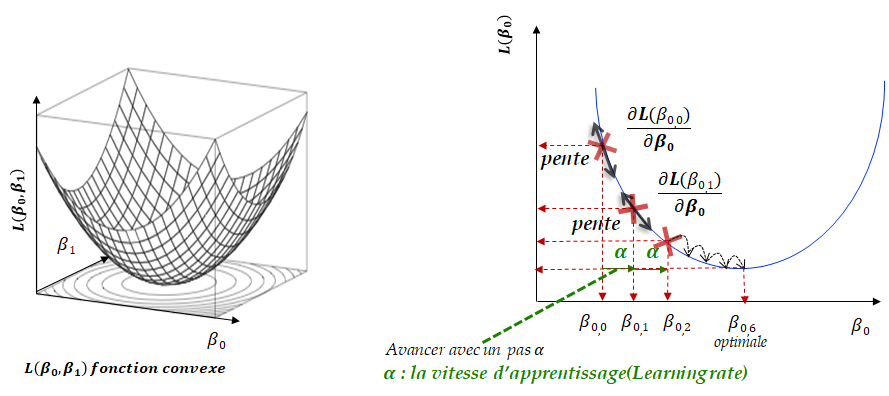




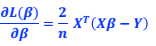

In [97]:
def grad(X,y,beta):
  n=len(y)
  return (2/n)*X.T.dot(model(X,beta)-y)

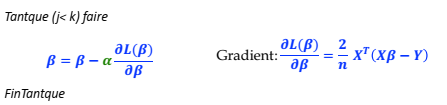

In [98]:
def gradient_descent(X,y,beta,learning_rate=0.001, n_iteration=1000):
   for i in range(n_iteration):
      beta=beta-learning_rate*grad(X,y,beta)
   return beta


In [99]:
beta_estimer=gradient_descent(X_train,y_train,beta,learning_rate=0.01, n_iteration=2000)


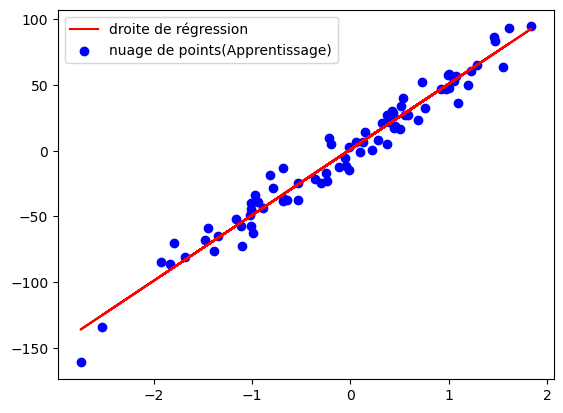

In [100]:
y_pred_train=model(X_train,beta_estimer)
plt.scatter(x_train,y_train,c='b',label="nuage de points(Apprentissage)")
plt.plot(x_train,y_pred_train, c='r',label="droite de régression" )
plt.legend()
plt.show()


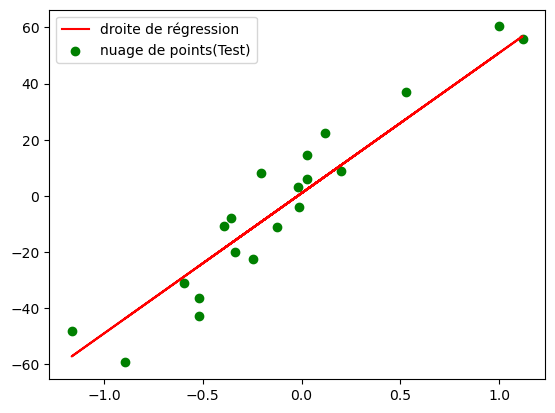

In [101]:
y_pred_test=model(X_test,beta_estimer)

plt.scatter(x_test,y_test,c='g',label="nuage de points(Test)")
plt.plot(x_test,y_pred_test, c='r',label="droite de régression" )
plt.legend()
plt.show()

# **Courbe d'apprentissage**

In [102]:
def gradient_descent_with_cost_history(X,y,beta,learning_rate=0.001, n_iteration=1000):
  cost_history=[]
  for i in range(n_iteration):
     beta=beta-learning_rate*grad(X,y,beta)
     cost_history.append(fonction_cout(X,beta,y))
  return beta, cost_history


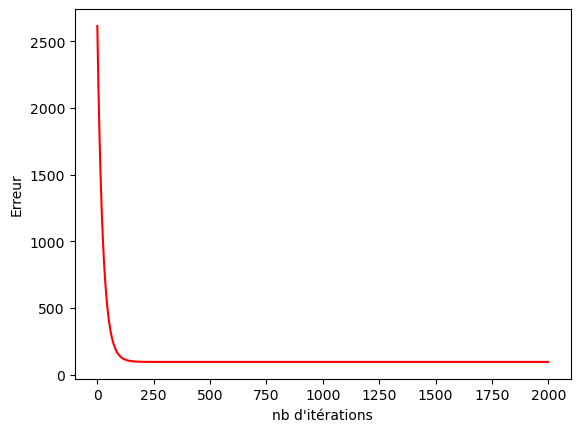

In [103]:
beta_estimer,cost_history=gradient_descent_with_cost_history(X_train,y_train,beta,learning_rate=0.01, n_iteration=2000)
plt.plot(cost_history,c='r')
plt.xlabel("nb d'itérations")
plt.ylabel("Erreur")
plt.show()

# Evaluation du modèle par l’analyse de la variance(Coefficient de détermination)

In [104]:
def coef_determination(y,y_pred):
  u=((y-y_pred)**2).sum()
  v=((y-y.mean())**2).sum()
  return 1-u/v

print(coef_determination(y_train,y_pred_train))
print(coef_determination(y_test,y_pred_test))


0.9635404378447257
0.8986817155028408


In [105]:
from sklearn.metrics import r2_score
print(r2_score(y_train,y_pred_train))
print(r2_score(y_test,y_pred_test))



0.9635404378447257
0.8986817155028408


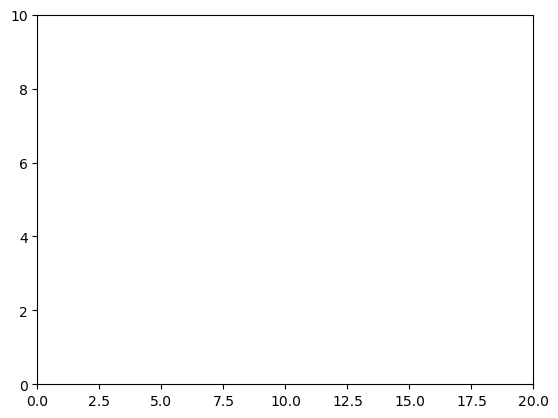

In [5]:
from IPython.display import HTML, Image
from random import randint

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# create empty lists for the x and y data
x = []
y = []

# create the figure and axes objects
fig, ax = plt.subplots()

def animate(i):
    pt = randint(1,9) # grab a random integer to be the next y-value in the animation
    x.append(i)
    y.append(pt)

    ax.clear()
    ax.plot(x, y)
    ax.set_xlim([0,20])
    ax.set_ylim([0,10])

ani = FuncAnimation(fig, animate, frames=20, interval=500, repeat=False)

plt.show()

HTML(ani.to_jshtml())

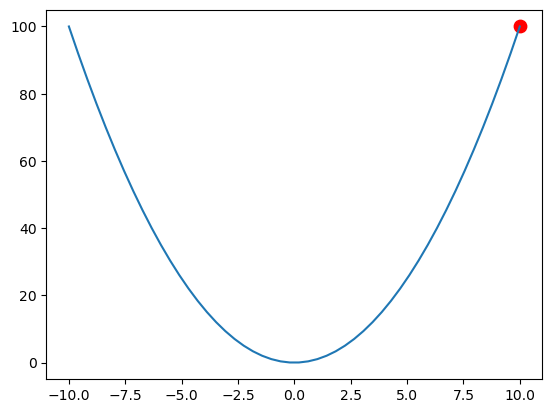

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
 
def f(x, record=False):
    y = x ** 2
    if record:
        global val_list
        val_list.append((np.round(x.numpy(), 3), np.round(y.numpy(), 3)))
    return y
 
 
val_list = []
tfx = tf.Variable(10.0)
opt = tf.keras.optimizers.SGD(learning_rate=0.1)
for i in range(0, 1000):
    opt.minimize(lambda: f(tfx, record=True), var_list=[tfx])
    if np.round(tfx.numpy(), 3) == 0.0:  # Added this condition to stop animation at the minimum value
        break
 
fig, ax = plt.subplots()
x = np.linspace(-10, 10)
y = f(x)
plt.plot(x, y)
 
def draw_step(i, val_list):
    if i!=0:
        ax.scatter(val_list[i-1][0], val_list[i-1][1], s=80, c='blue')
    
    ax.scatter(val_list[i][0], val_list[i][1], s=80, c='red')
 
 
ani = FuncAnimation(fig, draw_step, frames=len(val_list), fargs=(val_list,))
plt.show()

HTML(ani.to_jshtml())

In [80]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from matplotlib.animation import FuncAnimation
import plotly.graph_objects as go

start, end, step = -200, 200, 5
thetas_0, thetas_1 = np.arange(start, end, step), np.arange(start, end, step)
X,y=make_regression(n_samples=100, n_features=1, noise=10)
print(np.shape(x),np.shape(y))



def mse_cost(predictions, target):
    N = predictions.shape[0]
    diff = predictions.ravel() - target.ravel()
    cost = np.dot(diff, diff.T) / N
    return cost

def LinearModel(thetas, X):

    X = (X - X.mean()) / X.std()
    X = np.hstack((X, np.ones((X.shape[0], 1), dtype=X.dtype)))
    return np.dot(X, thetas)


thetas_lst = []
for theta_0 in thetas_0:
    for theta_1 in thetas_1:
        thetas_lst.append(np.array([theta_0, theta_1]).reshape(-1, 1))

linear_cost_lst = []       
for thetas in thetas_lst:
    # get prediction from our model
    pred_linear = LinearModel(thetas, X)

    linear_cost_lst.append(mse_cost(pred_linear, y))



thetas_lst = []
for theta_0 in thetas_0:
    for theta_1 in thetas_1:
        thetas_lst.append(np.array([theta_0, theta_1]).reshape(-1, 1))

linear_cost_lst = []       
for thetas in thetas_lst:
    pred_linear = LinearModel(thetas, X)
    linear_cost_lst.append(mse_cost(pred_linear, y))


(50,) (100,)


In [81]:
axis_length = len(np.arange(start, end, step))

linear_cost_matrix = np.array(linear_cost_lst).reshape(axis_length, axis_length)
                           


fig = go.Figure(data=go.Surface(z=linear_cost_matrix,
                                x=thetas_0,
                                y=thetas_1))

fig.update_traces(contours_z=dict(show=True, usecolormap=True,
                                  highlightcolor="limegreen", project_z=True))

fig.update_layout(title='Linear Model MSE Cost Surface',
                  scene=dict(
                    xaxis_title='theta_0 (intercept)',
                    yaxis_title='theta_1 (slope)',
                    zaxis_title='MSE Cost'),
                  width=700, height=700)

fig.show()

In [ ]:


def fonctionCoutB(X,y,beta0,beta1):
    n=len(y)
    term=model(X,beta0,beta1)-y
    return (1/n)*term.T.dot(term)

def fonctionCoutAll(x,y,Beta0,Beta1):
    
    erreurs=[]
    for i in range(len(Beta0)):
        for j in range(len(Beta1)):
            erreurs.append(fonctionCoutB(x,y,Beta0[i],Beta1[j]))
            
    return erreurs

def grad(X,y,beta0,beta1):
    n=len(y)
    return (2/n)*X.T.dot(model(X,beta0,beta1)-y)

def gradient_descent(X,y,beta0,beta1,learning_rate=0.001, n_iteration=1000):
    beta0List=[]
    beta1List=[]
    erreurs=[]
    for i in range(n_iteration):
        erreurs.append(fonctionCoutB(X,y,beta0,beta1))
        gradient=grad(X,y,beta0,beta1)
        beta0=beta0-learning_rate*gradient
        beta1=beta1-learning_rate*gradient
        beta0List.append(beta0)
        beta1List.append(beta1)
        #erreurs.append(fonctionCoutB(X,y,beta0,beta1))
    return beta0List,beta0List,erreurs

#fig, ax = plt.subplots()

ax = plt.figure().add_subplot(projection='3d')

#Beta0 = np.linspace(-160, 230)
#Beta1 = np.linspace(-160, 230)

start, end, step = -200, 200, 5
Beta0, Beta1 = np.arange(start, end, step), np.arange(start, end, step)
erreurs=fonctionCoutAll(x,y,Beta0,Beta1)
axis_length = len(np.arange(start, end, step))
linear_cost_matrix = np.array(erreurs).reshape(axis_length, axis_length)
#ax.plot(Beta1,erreurs[0,:] )
#ax.plot(Beta0,erreurs[:,0] )


#plt.ylim(np.min(erreurs[0,:]),np.max(erreurs[0,:]+5))
#plt.show()


import plotly.graph_objects as go

# plot the surface plot with plotly's Surface
fig = go.Figure(data=go.Surface(z=linear_cost_matrix,
                                x=Beta0,
                                y=Beta1))

# add a countour plot
fig.update_traces(contours_z=dict(show=True, usecolormap=True,
                                  highlightcolor="limegreen", project_z=True))

# annotate the plot
fig.update_layout(title='Linear Model MSE Cost Surface',
                  scene=dict(
                    xaxis_title='beta_0 (intercept)',
                    yaxis_title='beta1 (slope)',
                    zaxis_title='MSE Cost'),
                  width=700, height=700)

fig.show()






In [ ]:
beta0Init=Beta0[0]
beta1Init=Beta1[0]
beta0ListGradient,beta1ListGradient,erreursGradient=gradient_descent(x,y,beta0Init,beta1Init,learning_rate=0.001, n_iteration=300)

plt.ylim(np.min(erreursGradient),np.max(erreursGradient))
def draw_step(i):
    if i!=0:
        
        ax.scatter(beta0ListGradient[i-1], erreursGradient[i-1], s=80, c='blue')
    #else:
    ax.scatter(beta0ListGradient[i], erreursGradient[i], s=80, c='red')
    ax.set_ylim(np.min(erreursGradient),np.max(erreursGradient))
 
 
ani = FuncAnimation(fig, draw_step, frames=len(beta0ListGradient))
plt.show()
HTML(ani.to_jshtml())